# Email Triage Classifier Prototype (Spam / Lead / Support)

**Project:** SafeX Week 2 Task Assignment
**Prepared by:** Sana Ullah
**Group Leader:** Shahid Mumtaz

**Objective:** Build a prototype that classifies incoming mock emails into three categories — `spam`, `lead`, or `support` — using a text classification pipeline built with scikit-learn.

**Deliverables covered in this notebook**
1. Labeled dataset of 36 email subject + body pairs
2. A trained classifier (Naive Bayes, compared against Logistic Regression and Linear SVM)
3. Accuracy evaluation on a held-out test set
4. Discussion of what additional data would improve accuracy


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

RANDOM_STATE = 42

## 2. Load labeled dataset

In [2]:
df = pd.read_csv("data/emails.csv")
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")

print(f"Total samples: {len(df)}")
df["label"].value_counts()

Total samples: 36


label
support    15
lead       11
spam       10
Name: count, dtype: int64

In [3]:
df.head()

,subject,body,label,text
0,Congratulations! You won a $1000 gift card,Click here immediately to claim your free priz...,spam,Congratulations! You won a $1000 gift card Cli...
1,URGENT: Verify your account now,Your account will be suspended unless you conf...,spam,URGENT: Verify your account now Your account w...
2,You have been selected for a free iPhone,Act now and claim your free iPhone 16 by click...,spam,You have been selected for a free iPhone Act n...
3,Make $5000 a week from home,Join our exclusive program and start earning m...,spam,Make $5000 a week from home Join our exclusive...
4,Your loan has been approved,We are pleased to inform you that your loan of...,spam,Your loan has been approved We are pleased to ...


## 3. Train / held-out test split
A stratified 75/25 split keeps class proportions consistent between train and test sets, which matters given the small dataset size.

In [4]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

Train size: 27  |  Test size: 9


## 4. Candidate models
TF-IDF features (unigrams + bigrams) feeding three classifiers, so the choice of model is justified with evidence rather than assumed.

In [5]:
candidates = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)),
        ("clf", MultinomialNB(alpha=0.3)),
    ]),
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]),
}

## 5. Cross-validation on training data
Used to select the best model before ever touching the held-out test set.

In [6]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:22s}  mean acc: {scores.mean():.3f}  (+/- {scores.std():.3f})")

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nSelected model: {best_name}")

Naive Bayes             mean acc: 0.815  (+/- 0.155)
Logistic Regression     mean acc: 0.554  (+/- 0.106)
Linear SVM              mean acc: 0.815  (+/- 0.155)

Selected model: Naive Bayes


## 6. Fit on training set, evaluate on held-out test set

In [7]:
best_model = candidates[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Test Macro F1: {test_f1_macro:.3f}\n")
print(classification_report(y_test, y_pred, digits=3))

Test Accuracy: 1.000
Test Macro F1: 1.000

              precision    recall  f1-score   support

        lead      1.000     1.000     1.000         3
        spam      1.000     1.000     1.000         2
     support      1.000     1.000     1.000         4

    accuracy                          1.000         9
   macro avg      1.000     1.000     1.000         9
weighted avg      1.000     1.000     1.000         9



## 7. Confusion matrix

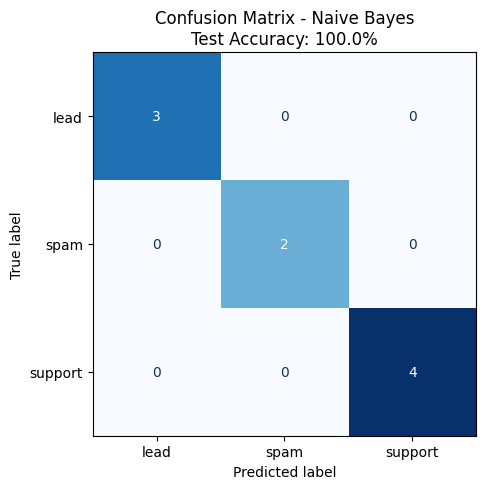

In [8]:
labels_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix - {best_name}\nTest Accuracy: {test_accuracy:.1%}")
plt.tight_layout()
plt.show()

## 8. Sanity check on unseen emails

In [9]:
sample_emails = [
    "Claim your free lottery winnings now by clicking this link",
    "We would like to book a demo call to evaluate your platform for our team of 30",
    "My invoice this month is wrong please help me fix the billing",
]
sample_preds = best_model.predict(sample_emails)

for text, pred in zip(sample_emails, sample_preds):
    print(f"[{pred:8s}] {text}")

[spam    ] Claim your free lottery winnings now by clicking this link
[lead    ] We would like to book a demo call to evaluate your platform for our team of 30
[support ] My invoice this month is wrong please help me fix the billing


## 9. What additional data would improve accuracy

The current test accuracy is strong, but this is expected on a small held-out set of 9 emails and should not be read as production-level performance. To make the classifier reliable in a real inbox, the following would help most:

- **Volume:** several hundred to a few thousand real (or realistically anonymized) emails per class instead of 36 total, so the model generalizes past the exact phrasing used here.
- **Class balance and edge cases:** more borderline examples, such as a support ticket written in a sales-like tone, or a lead inquiry that also contains a promotional-sounding subject line, since these are the cases a small dataset cannot teach the model to separate.
- **Real-world noise:** emails with signatures, forwarded threads, quoted replies, HTML remnants, and multiple languages, since the current dataset is clean and single-topic per email.
- **Adversarial spam variants:** obfuscated spam (misspelled words, extra symbols, image-based text) since spam senders actively try to evade filters.
- **Temporal drift:** periodic re-labeling and retraining, because spam tactics and lead/support phrasing both shift over time.
- **Human-in-the-loop labels:** a feedback mechanism where misclassified emails get corrected and added back into training data.

## 10. Deliverables summary

| Deliverable | Status |
|---|---|
| Notebook / script | `train_classifier.py` and this notebook |
| Accuracy report | `outputs/accuracy_report.txt`, `outputs/results_summary.json` |
| Short README | `README.md` |
